# 4 &middot; Elastostatics as a Minimization Problem

Posing an elastic object is an **optimization**: find the vertex positions
\(x\) that minimize
$$ E(x) = \underbrace{E_{\text{elastic}}(x)}_{\text{wants rest shape}}
        + \underbrace{\tfrac{K}{2}\lVert x_{\text{pin}} - p\rVert^2}_{\text{hold pins}}
        + \underbrace{\tfrac{K}{2}\lVert x_{\text{handle}} - h\rVert^2}_{\text{drag handle}}. $$

We pin part of the shape, drag a **handle**, and let everything else settle. The
pin/handle terms are quadratic *spring* penalties from
`simkit.dirichlet_penalty`. We minimize silently with Newton (the solver is
tutorial 5's job) and focus on how **different energies pose differently**.

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
import simkit.energies as energies
from simkit.solvers import newton_solver
import utils
os.makedirs("media", exist_ok=True)

## A small, readable objective

`make_material` picks the elastic model (its energy / gradient / PSD-projected
Hessian, all with the same signature). `ElasticPose` adds two spring terms
&mdash; a fixed **pin** and a movable **handle** &mdash; and exposes
`energy / gradient / hessian` for the Newton solver.

In [2]:
def make_material(name):
    """(energy, gradient, hessian) of the elastic term, uniform (xn, J, mu, lam, vol) signature."""
    E = energies
    if name == "ARAP":          # ARAP uses only mu
        return (lambda xn, J, mu, lam, vol: E.arap_energy_x(xn, J, mu, vol),
                lambda xn, J, mu, lam, vol: E.arap_gradient_x(xn, J, mu, vol),
                lambda xn, J, mu, lam, vol: E.arap_hessian_x(xn, J, mu, vol, psd=True))
    if name == "Linear":
        return (E.linear_elasticity_energy_x, E.linear_elasticity_gradient_x,
                lambda xn, J, mu, lam, vol: E.linear_elasticity_hessian_x(xn, J, mu, lam, vol, psd=True))
    return (E.macklin_mueller_neo_hookean_energy_x, E.macklin_mueller_neo_hookean_gradient_x,
            lambda xn, J, mu, lam, vol: E.macklin_mueller_neo_hookean_hessian_x(xn, J, mu, lam, vol, psd=True))


class ElasticPose:
    """Minimize  elastic(x) + pin spring + handle spring."""

    def __init__(self, X, T, material="Neo-Hookean", K=1e5):
        self.X, self.T, self.K = X, T, K
        self.n, self.dim = X.shape
        self.J, self.vol = simkit.deformation_jacobian(X, T), simkit.volume(X, T)
        self.mu  = np.full((len(T), 1), 1.0)
        self.lam = np.full((len(T), 1), 1.0)
        self.elastic_energy, self.elastic_grad, self.elastic_hess = make_material(material)
        self.pin = self._spring([], np.empty((0, self.dim)))      # (Q, b)
        self.handle = self._spring([], np.empty((0, self.dim)))

    def _spring(self, idx, targets):
        return simkit.dirichlet_penalty(np.atleast_1d(np.asarray(idx, int)),
                                        np.atleast_2d(targets), self.n, self.K)

    def set_pin(self, idx, targets):     self.pin = self._spring(idx, targets)
    def set_handle(self, idx, targets):  self.handle = self._spring(idx, targets)

    # spring penalty 1/2 x^T Q x + b^T x, and its gradient / Hessian
    @staticmethod
    def _spring_energy(Qb, xc):  Q, b = Qb; return 0.5 * (xc.T @ (Q @ xc))[0, 0] + (b.T @ xc)[0, 0]
    @staticmethod
    def _spring_grad(Qb, xc):    Q, b = Qb; return Q @ xc + b

    def energy(self, x):
        xn, xc = x.reshape(-1, self.dim), x.reshape(-1, 1)
        E_elastic = self.elastic_energy(xn, self.J, self.mu, self.lam, self.vol)
        E_pin     = self._spring_energy(self.pin, xc)
        E_handle  = self._spring_energy(self.handle, xc)
        E_total   = E_elastic + E_pin + E_handle
        return E_total

    def gradient(self, x):
        xn, xc = x.reshape(-1, self.dim), x.reshape(-1, 1)
        g_elastic = self.elastic_grad(xn, self.J, self.mu, self.lam, self.vol)
        g_pin     = self._spring_grad(self.pin, xc)
        g_handle  = self._spring_grad(self.handle, xc)
        g_total   = g_elastic + g_pin + g_handle
        return g_total

    def hessian(self, x):
        xn = x.reshape(-1, self.dim)
        H_elastic = self.elastic_hess(xn, self.J, self.mu, self.lam, self.vol)
        H_pin     = self.pin[0]                          # Q of the pin spring
        H_handle  = self.handle[0]                       # Q of the handle spring
        H_total   = H_elastic + H_pin + H_handle
        return H_total

    def solve(self, U0, iters=30):
        x = newton_solver(U0.reshape(-1, 1), self.energy, self.gradient, self.hessian, max_iter=iters, do_line_search=True)
        return x.reshape(self.n, self.dim)

## A triangle: pin the left vertex, swing the right one in a figure-8

The pinned vertex stays put, the handle traces a **figure-8** (so we see the
free apex both stretch and compress), and the apex follows differently for each
elastic model.


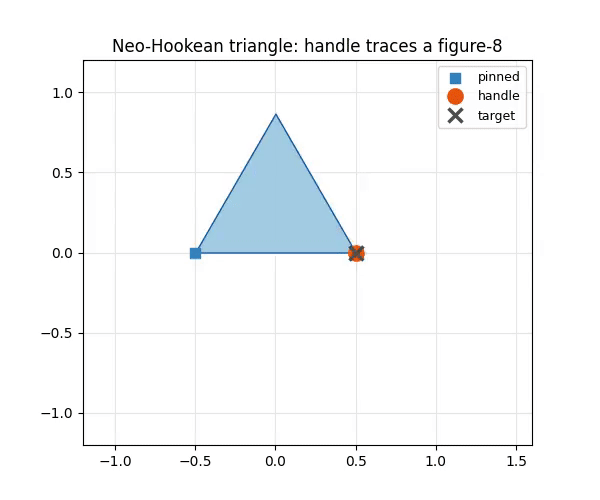

In [3]:
X = np.array([[-0.5, 0.0], [0.5, 0.0], [0.0, np.sqrt(3) / 2]])
T = np.array([[0, 1, 2]])
PIN, HANDLE = 0, 1

# figure-8 (lemniscate) traced by the handle, starting from rest (t=0 -> no offset)
t = np.linspace(0, 2 * np.pi, 48)
fig8 = np.stack([0.45 * np.sin(t), 0.6 * np.sin(2 * t)], axis=1)   # half as wide as before
handle_path = X[HANDLE] + fig8

def run(material):
    pose = ElasticPose(X, T, material)
    pose.set_pin(PIN, X[PIN])
    states, U = [], X.copy()
    for h in handle_path:
        pose.set_handle(HANDLE, h)
        U = pose.solve(U)
        states.append(U.copy())
    return states

states = run("Neo-Hookean")
fig, anim = utils.animate_mesh(states, T, lims=((-1.2, 1.6), (-1.2, 1.2)),
    title="Neo-Hookean triangle: handle traces a figure-8",
    pin_pts=X[[PIN]], handle_traj=[s[HANDLE] for s in states],
    target_pts=list(handle_path), fps=20, figsize=(6, 5))
utils.save_anim(anim, "media/04_triangle.mp4", fps=20)
plt.close(fig)
utils.show_anim(anim)

## Same handle, three energies, very different poses

Pull the handle far up-and-right and compare where the free apex lands under each
model. Linear elasticity (no rotation-invariance) reacts quite differently from
ARAP and Neo-Hookean.

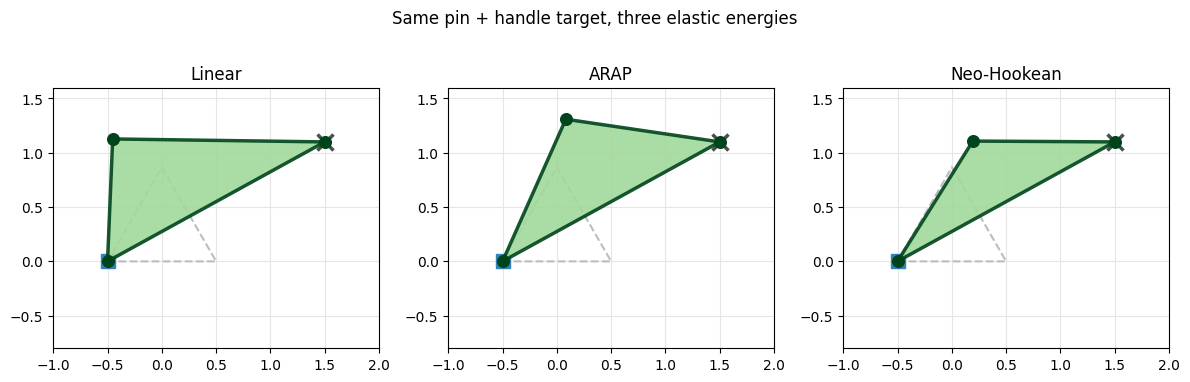

In [4]:
target = np.array([1.5, 1.1])
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, material in zip(axes, ["Linear", "ARAP", "Neo-Hookean"]):
    pose = ElasticPose(X, T, material)
    pose.set_pin(PIN, X[PIN]); pose.set_handle(HANDLE, target)
    U = pose.solve(X.copy())
    utils.setup_axes(ax, (-1.0, 2.0), (-0.8, 1.6), title=material)
    utils.TriangleArtist(ax, U, rest=X)
    ax.plot(*X[PIN], "s", color=utils.PIN_C, ms=10)
    ax.plot(*target, "x", color="0.3", ms=12, mew=2.5)
fig.suptitle("Same pin + handle target, three elastic energies")
fig.tight_layout(); plt.show()

## A cantilever beam: pin the left edge, swing the whole right edge

The handle is now **every vertex on the right edge** (not one). We **rotate those
target points about the origin** &mdash; the orange handles swing up and down in a
wide arc &mdash; which whips the beam through large bends. Starting from rest, the
angle sweeps to about \(\pm 120^\circ\) and back. Targets are marked with an
**&times;**.


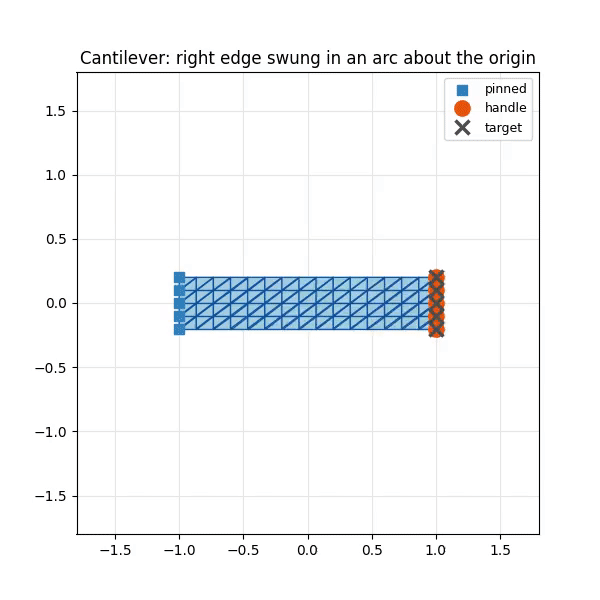

In [5]:
Xb, Tb = utils.triangulated_grid(nx=16, ny=5, width=2.0, height=0.4)
pin_idx   = np.where(Xb[:, 0] <= Xb[:, 0].min() + 1e-6)[0]
right_idx = np.where(Xb[:, 0] >= Xb[:, 0].max() - 1e-6)[0]

# rotate the right-edge target points about the ORIGIN; angle swings +/-120 deg from rest
angles = np.deg2rad(120) * np.sin(np.linspace(0, 2 * np.pi, 48))
def rotate_about_origin(P, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    return P @ R.T

beam = ElasticPose(Xb, Tb, "Neo-Hookean")
beam.set_pin(pin_idx, Xb[pin_idx])
states, targets, U = [], [], Xb.copy()
for th in angles:
    tgt = rotate_about_origin(Xb[right_idx], th)
    beam.set_handle(right_idx, tgt)
    U = beam.solve(U)
    states.append(U.copy()); targets.append(tgt.copy())

fig, anim = utils.animate_mesh(states, Tb, lims=((-1.8, 1.8), (-1.8, 1.8)),
    title="Cantilever: right edge swung in an arc about the origin",
    pin_pts=Xb[pin_idx],
    handle_traj=[s[right_idx] for s in states], target_pts=targets, fps=20,
    figsize=(6, 6))
utils.save_anim(anim, "media/04_beam.mp4", fps=20)
plt.close(fig)
utils.show_anim(anim)

### Takeaways
* Posing = **minimizing** elastic energy + soft pin/handle springs.
* The *same* setup with a *different* energy gives a *different* equilibrium.
* We solved it silently with Newton. **How** that solve works is next.